In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Hochschule Emden/Leer' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/01bc76c69' -- 'Hochschule Emden/Leer'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Hochschule Emden/Leer,"University of Applied Sciences Emden/Leer, Emd...",https://openalex.org/W4312541336
1,not assigned,Hochschule Emden/Leer,"University of Applied Sciences Emden/Leer, Con...",https://openalex.org/W4210538574
2,not assigned,Hochschule Emden/Leer,"Department of Mechanical Engineering, Universi...",https://openalex.org/W4220982488
3,not assigned,Hochschule Emden/Leer,"University of Applied Sciences, Emden/Leer, Ge...",https://openalex.org/W4360986015
4,not assigned,Hochschule Emden/Leer,"University of Applied Sciences Emden/Leer, Ins...",https://openalex.org/W4297796207


In [6]:
MAPPING_DICT = {
    'Fachbereich Seefahrt und maritime Wissenschaften': ['maritime (sciences|mobility)', 'nautical'],
    'Fachbereich Soziale Arbeit und Gesundheit': ['so(z|c)ial', 'public health', 'life sciences'],
    'Fachbereich Technik': ['technology', 'engineering', 'laser', 'informatic', 'energies', 'fachbereich technik', 'machine dynamics', 'maschinendynamik',
                            'solar energy', 'mixed reality lab', 'physical chemistry'
                           ],
    'Fachbereich Wirtschaft': ['wirtschaft', 'business', 'finanzmanagement', 'economics']
    # 'Hochschulbibliothek': [''],
}

In [7]:
with open('./mapping_tables_fak/emden.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [8]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [9]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [10]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,None,Hochschule Emden/Leer,"University of Applied Sciences Emden/Leer, Emd...",https://openalex.org/W4312541336
1,None,Hochschule Emden/Leer,"University of Applied Sciences Emden/Leer, Con...",https://openalex.org/W4210538574
2,Fachbereich Technik,Hochschule Emden/Leer,"Department of Mechanical Engineering, Universi...",https://openalex.org/W4220982488
3,None,Hochschule Emden/Leer,"University of Applied Sciences, Emden/Leer, Ge...",https://openalex.org/W4360986015
4,Fachbereich Technik,Hochschule Emden/Leer,"University of Applied Sciences Emden/Leer, Ins...",https://openalex.org/W4297796207
...,...,...,...,...
409,Fachbereich Soziale Arbeit und Gesundheit,Hochschule Emden/Leer,"Department of Social Work and Health, Universi...",https://openalex.org/W4414013644
410,Fachbereich Soziale Arbeit und Gesundheit,Hochschule Emden/Leer,"Department of Social Work and Health, Universi...",https://openalex.org/W4412524005
411,Fachbereich Soziale Arbeit und Gesundheit,Hochschule Emden/Leer,"Department of Social Work and Health, Universi...",https://openalex.org/W4406435882
412,Fachbereich Technik,Hochschule Emden/Leer,"University of Applied Sciences Emden/Leer, Ins...",https://openalex.org/W4389661824


In [11]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['University of Applied Sciences Emden/Leer, Emden, Germany, --- Select a Country ---',
       'University of Applied Sciences Emden/Leer, Constantiaplatz 4, 26723 Emden, Germany',
       'University of Applied Sciences, Emden/Leer, Germany',
       'University of Applied Science Emden/Leer, Germany',
       'University of Applied Sciences Emden Leer',
       'Hochschule Emden-Leer, Emden, Germany',
       'Univ. of Applied Sciences Emden/Leer (Germany)',
       'University of Applied Sciences Emden / Leer, Hamburg, Germany',
       'University of Applied Sciences Emden/Leer, Germany and University of Seville, Spain',
       'University of Applied Sciences Emden/Leer',
       'University of Applied Sciences Emden-Leer',
       'University of Applied Science Emden/Leer, Emden, Germany',
       'University of Applied Sciences Emden/Leer , Emden, Germany',
       'University of Applied Sciences Emden/Leer, Brandeis University , Emden, Germany',
       'University of Applied Sciences

In [12]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Fachbereich Seefahrt und maritime Wissenschaften,8
1,Fachbereich Soziale Arbeit und Gesundheit,63
2,Fachbereich Technik,134
3,Fachbereich Wirtschaft,8
4,NaN,201


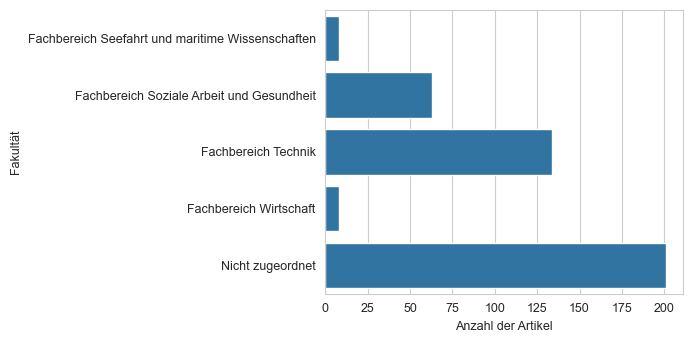

In [13]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 3.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [14]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.5144927536231884

In [15]:
MAPPING_DICT_DEPT = {
    #'Fachbereich Seefahrt und maritime Wissenschaften': {},
    'Fachbereich Soziale Arbeit und Gesundheit': {
        'Institut für Sozial- und Gesundheitswissenschaften Emden (ISGE)': []
    },
    'Fachbereich Technik': {
        'Institut für Informatik, Automatisierungstechnik und Robotik (I²AR)': ['computer science', 'robotics', 'informatics and electronics',
                                                                                'electrical engineering', 'industrial informatics'
                                                                               ],
        #'Institut für Integrierte Produktentwicklung (IIP)': [],
        'Institut für Laser und Optik': ['laser(s)? (und|and) opti(k|cs)'],
        'Institut für Maschinen- und Anlagenbau (MABI)': ['mechanical engineering', 'hyperloop', 'maschinendynamik'],
        #'Institut für Medien und Technik (IMuT)': [],
        #'Institut für Nachrichtentechnik / Kommunikationssysteme (INK)': [],
        #'Institut für Umwelttechnik - EUTEC': [],
        #'Labor für Werkstoffkunde und Fügetechnik': [],
        #'Studiengang Biotechnologie/Bioinformatik': [],
        #'Studiengang Elektrotechnik': [],
        #'Studiengang Wirtschaftsinformatik
    },
    #'Fachbereich Wirtschaft': {},
    #'Hochschulbibliothek': {}
}

In [16]:
with open('./mapping_tables_dept/emden.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [17]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [18]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich Technik', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich Technik']['raw_affiliation_string'].apply(map_dept, 
                                                                                                    faculty='Fachbereich Technik')

In [19]:
df_with_inst[(df_with_inst['fak_name'] == 'Fachbereich Technik') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[20:]

array(['Hochschule Emden/Leer,Laboratory for Renewable Energies,Emden,Germany',
       'Faculty of Technology, University of Applied Science Emden/Leer, Emden, Germany',
       'Faculty of Technology, University of Applied Science Emden/Leer, Emden, Germany, --- Select a Country ---',
       'Department of Microbiology-Biotechnology, Faculty of Technology, University of Applied Sciences Emden/Leer, 26723 Emden, Germany;',
       'Faculty of Technology, University of Applied Sciences Emden/Leer, Emden, GERMANY',
       'Faculty of Technology, University of Applied Sciences Emden/Leer, Constantiaplatz 4, 26723 Emden, Germany',
       'Hochschule Emden/Leer, Fachbereich Technik – Abt. N  Constantiaplatz 4 26723 Emden Germany',
       'Department of Microbiology—Biotechnology, University of Applied Sciences Emden Leer, 26723 Emden, Germany',
       'Faculty of Technology, Microbiology – Biotechnology, University of Applied Sciences Emden/Leer, Emden, Germany',
       'Machine Dynamics Labo

In [20]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich Technik'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,"Institut für Informatik, Automatisierungstechn...",34
1,Institut für Laser und Optik,16
2,Institut für Maschinen- und Anlagenbau (MABI),10
3,NaN,74


In [21]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich Technik']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
2,Fachbereich Technik,Hochschule Emden/Leer,"Department of Mechanical Engineering, Universi...",https://openalex.org/W4220982488,Institut für Maschinen- und Anlagenbau (MABI)
4,Fachbereich Technik,Hochschule Emden/Leer,"University of Applied Sciences Emden/Leer, Ins...",https://openalex.org/W4297796207,Institut für Laser und Optik
5,Fachbereich Technik,Hochschule Emden/Leer,"Institute for Industrial Informatics, Automati...",https://openalex.org/W4292258978,"Institut für Informatik, Automatisierungstechn..."
6,Fachbereich Technik,Hochschule Emden/Leer,"Faculty of Technology, University of Applied S...",https://openalex.org/W4296079582,None
7,Fachbereich Technik,Hochschule Emden/Leer,"University of Applied Sciences Emden/Leer,Facu...",https://openalex.org/W4296079582,None
...,...,...,...,...,...
400,Fachbereich Technik,Hochschule Emden/Leer,Institut für Laser und Optik Hochschule Emden/...,https://openalex.org/W3097374035,Institut für Laser und Optik
402,Fachbereich Technik,Hochschule Emden/Leer,Department of Electrotechnical and Industrial ...,https://openalex.org/W3111221273,"Institut für Informatik, Automatisierungstechn..."
405,Fachbereich Technik,Hochschule Emden/Leer,"Institute for Laser and Optics (ILO), Universi...",https://openalex.org/W3192346900,Institut für Laser und Optik
408,Fachbereich Technik,Hochschule Emden/Leer,"University of Applied Sciences Emden/Leer, Fac...",https://openalex.org/W7117113280,None


In [22]:
MAPPING_DICT_INST = {}

In [23]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Hochschule Emden/Leer'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/emden.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)